## Гауссово распределение, линейный дискриминантный анализ и наивный байес

### 1. Многомерное гауссово распределение
Создайте случайную выборку данных с двумерным гауссовым распределением. Для этого сперва сделайте два вектора из двух одномерных распределений с разными стандартными отклонениями $\sigma_1$ и $\sigma_2$, как показано ниже:  
``` python
import numpy as np

M = 200
sigma1 = 0.1
sigma2 = 0.5
x1 = np.random.randn(M, 1) * sigma1
x2 = np.random.randn(M, 1) * sigma2
X = np.concatenate((x1, x2), axis=1)
```
После чего сделайте матрицу поворота на угол $\alpha$ и с помощью неё поверните набор точек в пространстве.  
Посчитайте матрицу ковариации для сгенерированных точек.  
Нарисуйте полученное облако точек и сравните его с облаком точек, полученных с помощью готовой функции:  `np.random.multivariate_normal()`


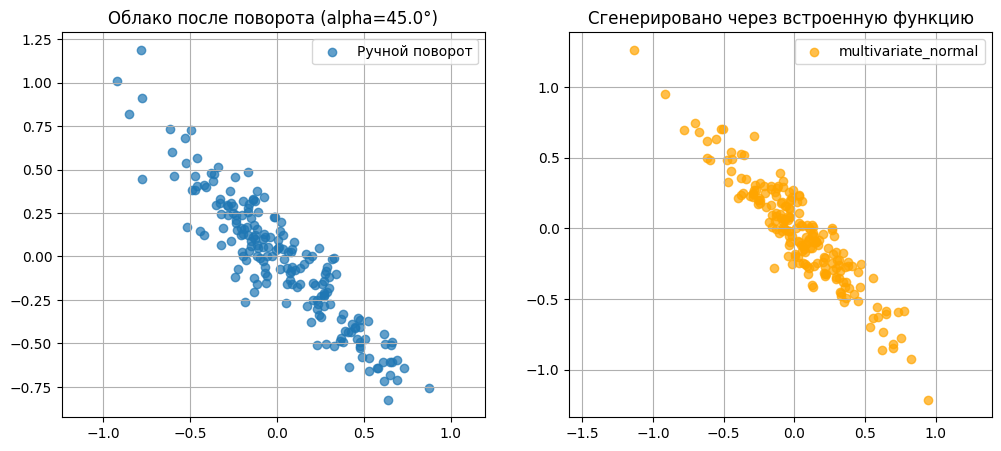

Полученная матрица ковариации:
 [[ 0.12331584 -0.11711127]
 [-0.11711127  0.1312253 ]]


In [1]:
import numpy as np
from matplotlib import pyplot as plt

# 1. Создание выборки
M = 200
sigma1 = 0.1
sigma2 = 0.5
x1 = np.random.randn(M, 1) * sigma1
x2 = np.random.randn(M, 1) * sigma2
X = np.concatenate((x1, x2), axis=1)

# 2. Матрица поворота (например, на 45 градусов)
alpha = np.pi / 4 
R = np.array([
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha),  np.cos(alpha)]
])

# Поворот точек
X_rot = X @ R.T

# 3. Расчет матрицы ковариации
# Для np.cov признаки должны быть в строках, поэтому транспонируем X_rot
cov_matrix = np.cov(X_rot.T)
mean_vector = np.mean(X_rot, axis=0)

# 4. Генерация с помощью np.random.multivariate_normal
X_builtin = np.random.multivariate_normal(mean_vector, cov_matrix, M)

# 5. Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_rot[:, 0], X_rot[:, 1], alpha=0.7, label='Ручной поворот')
plt.title(f'Облако после поворота (alpha={np.degrees(alpha)}°)')
plt.axis('equal')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_builtin[:, 0], X_builtin[:, 1], alpha=0.7, color='orange', label='multivariate_normal')
plt.title('Сгенерировано через встроенную функцию')
plt.axis('equal')
plt.grid(True)
plt.legend()

plt.show()

print("Полученная матрица ковариации:\n", cov_matrix)

### 2. Плотность вероятности гауссового распределения
В общем виде $n$-мерное гауссово распределение имеет вид:  
$$p(x) = \frac{1}{(\sqrt{2\pi})^n \sqrt{detC}} e^{-\frac{1}{2}(x-\mu)^TС^{-1}(x-\mu)} \tag{1}$$  
где $x\in{R^n}$, $\mu\in{R^n}$ - среднее значение, $C$ - матрица ковариации.  

Сгенерируйте набор точек в двумерном пространстве (как делали в пункте 1 или другим способом). Посчитайте для них среднее значение и матрицу ковариации $\mu$ и $C$. Для оценки плотности вероятности (probability density function - `pdf`) гауссового распределения в произвольной точке используйте `scipy.stats.multivariate_normal` 
(https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html), либо можете посчитать вручную.  

Визуализируйте набор точек и плотность вероятности, для чего изобразите точки одним цветом, а фон раскрасьте в соответсвии с плотностью вероятности, для чего можете использовать пример ниже:  

``` python
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import multivariate_normal

xx = np.linspace(-1, 1, 100)
yy = np.linspace(-1, 1, 100)
XX, YY = np.meshgrid(xx, yy)
pp = np.stack((XX.flatten(), YY.flatten()), axis=1)
m = multivariate_normal(mean=[0,0], cov=[[0.3, 0], [0, 0.1]])
ZZ = m.pdf(pp).reshape(XX.shape)

IMG = plt.pcolor(XX, YY, ZZ)
plt.colorbar(IMG)

CS = plt.contour(XX, YY, m.pdf(pp).reshape(XX.shape), levels=[0.2, 0.4, 0.6, 0.8, 0.9], colors='k')
plt.clabel(CS, inline=1, fontsize=10)
```

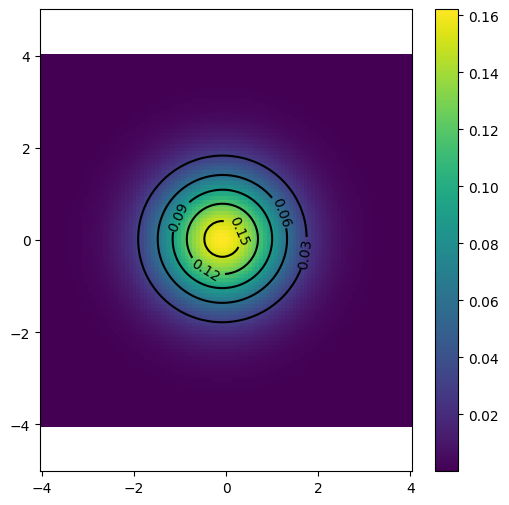

Среднее значение: [-0.08034075  0.02964576]
Ковариационная матрица:
 [[0.99210546 0.0031975 ]
 [0.0031975  0.96974316]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

M = 200
X = np.random.randn(M, 2)

mean = np.mean(X, axis=0)
cov = np.cov(X.T)

xx = np.linspace(-4, 4, 100)
yy = np.linspace(-4, 4, 100)
XX, YY = np.meshgrid(xx, yy)
pp = np.stack((XX.flatten(), YY.flatten()), axis=1)

m = multivariate_normal(mean=mean, cov=cov)
ZZ = m.pdf(pp).reshape(XX.shape)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c='red', alpha=0.5)
IMG = plt.pcolor(XX, YY, ZZ, shading='auto')
plt.colorbar(IMG)
CS = plt.contour(XX, YY, ZZ, levels=5, colors='k')
plt.clabel(CS, inline=1, fontsize=10)
plt.axis("equal")
plt.show()

print("Среднее значение:", mean)
print("Ковариационная матрица:\n", cov)


### 3. Бинарная классификация

**Задание** 
Создайте случайный датасет, состоящий из двух классов $y\in{\{0, 1\}}$, а признаки имеют две координаты. Посчитайте для каждого класса среднее значение и матрицу ковариации $\mu_0, \mu_1$ и $C_0, C_1$.

Решение задачи классификации можно свести к оценке максимальной апостериорной вероятности (Maximum a posterior - MAP):
$$y = \underset{y\in{0,1}}{argmax} p(y|x) \tag{2}$$  
которая в свою очередь через теорему Байеса равна:  
$$p(y|x) = \frac{p(x|y)p(y)}{p(x)} \tag{3}$$
В последней формуле вероятность p(y) называется априорной и не зависит от $x$ - оценить её можно просто как долю точек датасета принадлежащего заданному классу $y$. Вероятность p(x|y) называют правдоподобием (likelyhood). Обычно правдоподобие моделируется некоторой генерирующей моделью, например по формуле гаусса (1), и говорит насколько правдоподобно что точка с координатами $x$ могла быть "сгенерирована" в классе $y$. Знаменатель $p(x)$ в последней формуле не зависит от $y$, поэтому на него внимание не обращаем.  

Таким образом, для бинарной классификации, т.е. для оценки принадлежности некоторой точки $x$ к классу 0 или 1, нужно сравнить две величины:  
$$p(x|y=0)p(y=0) \overset{?}{<>} p(x|y=1)p(y=1) \tag{4}$$

**Задание**
Визуализируейте на одном рисунке датасет с точками обоих классов разными цветами. Раскрасьте фон изображения в соответствии с разностью левой и правой частей уравнения (4). Постройте на этом же рисунке разделяющую кривую, т.е. кривую соответствующую нулевой разнице между левой и правой частями. Для её построения используйте функции `plt.contour` с указанием конкретного уровня.

### 5. Наивный байесовый классификатор (NaiveBayes)

**Задание** 
Прочитать по наивный байесовый подход можно здесь (https://scikit-learn.org/stable/modules/naive_bayes.html) или в учебнике Яндекса по ML (https://education.yandex.ru/handbook/ml/article/generativnyj-podhod-k-klassifikacii).  

Суть наивного предположения состоит в том, чтобы не считать совместную плотность вероятности для $n$-мерного случая, а рассматривать каждую переменную как независимую и считать одномерные распределения:  
$$p(x_1,x_2,...,x_n|y) => \prod\limits_{i=1}^{n}p(x_i|y)$$  
Это можно также рассматривать как обнуление всех внедиагональных элементов матрицы ковариации.  

**Задание** 
Реализуйте классификатор на основе наивного байесового подхода с одномерным гауссовым распределением для каждой переменной. Желательно сделать реализацию, которая подходит не только для двумерного, но и для более общего случая.

```python
from sklearn.base import BaseEstimator

class myNB(BaseEstimator):
    def __init__(self):
        pass
    
    def fit(self, X, y):
        pass
    
    def predict(self, X):
        pass
```

C:\Users\DIMA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


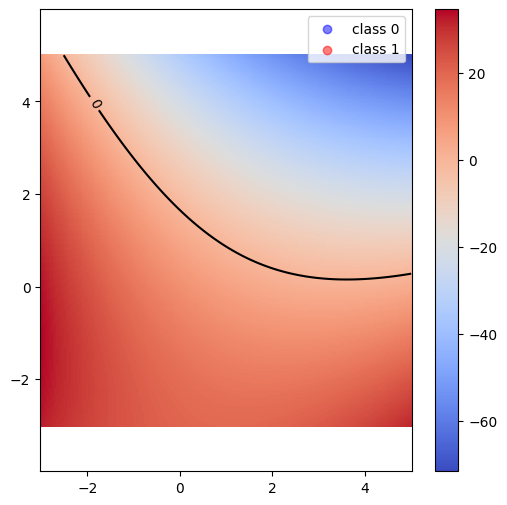

Среднее класса 0: [-0.05092442  0.00666975]
Ковариация класса 0:
 [[ 0.49827669 -0.0135342 ]
 [-0.0135342   0.19245765]]
Среднее класса 1: [2.08902866 2.00708625]
Ковариация класса 1:
 [[0.30960319 0.08800825]
 [0.08800825 0.28787618]]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(0)
M = 200
X0 = np.random.multivariate_normal([0,0], [[0.5,0],[0,0.2]], M)
X1 = np.random.multivariate_normal([2,2], [[0.3,0.1],[0.1,0.3]], M)

mean0 = np.mean(X0, axis=0)
cov0 = np.cov(X0.T)
mean1 = np.mean(X1, axis=0)
cov1 = np.cov(X1.T)

prior0 = len(X0) / (len(X0)+len(X1))
prior1 = len(X1) / (len(X0)+len(X1))

xx = np.linspace(-3,5,200)
yy = np.linspace(-3,5,200)
XX, YY = np.meshgrid(xx, yy)
pp = np.stack((XX.flatten(), YY.flatten()), axis=1)

m0 = multivariate_normal(mean0, cov0)
m1 = multivariate_normal(mean1, cov1)

Z = np.log(m0.pdf(pp)*prior0) - np.log(m1.pdf(pp)*prior1)
Z = Z.reshape(XX.shape)

plt.figure(figsize=(6,6))
plt.scatter(X0[:,0], X0[:,1], c='blue', alpha=0.5, label='class 0')
plt.scatter(X1[:,0], X1[:,1], c='red', alpha=0.5, label='class 1')
IMG = plt.pcolor(XX, YY, Z, cmap='coolwarm', shading='auto')
plt.colorbar(IMG)
CS = plt.contour(XX, YY, Z, levels=[0], colors='k')
plt.clabel(CS, inline=1, fontsize=10)
plt.legend()
plt.axis("equal")
plt.show()

print("Среднее класса 0:", mean0)
print("Ковариация класса 0:\n", cov0)
print("Среднее класса 1:", mean1)
print("Ковариация класса 1:\n", cov1)

### 4. LDA (linear discriminant analysis)

**Задание** Рассмотрите частный случай, когда для точек двух классов матрицы ковариации совпадают, т.е. $C_0=C_1$, но средние значения отличаются $\mu_0\neq\mu_1$. Выпишите явное выражение для разделяющей поверхности в этом случае. Визуализируйте такой случай аналогично предыдущему пункту. Про линейный и квадратичный дискриминантный анализ можете почитать здесь (https://scikit-learn.org/stable/modules/lda_qda.html) или в учебнике Яндекса по ML (https://education.yandex.ru/handbook/ml/article/generativnyj-podhod-k-klassifikacii)

Реализуйте классификатор на основе метода линейного дискриминантного анализа по шаблону ниже. Данный алгоритм предполагает одинаковость матриц ковариации (т.е. считает одну общую матрицу ковариации, но разные средние) и использует линейное правило классификации. Желательно сделать реализацию, которая подходит не только для двумерного, но и для более общего случая.

```python
from sklearn.base import BaseEstimator

class myLDA(BaseEstimator):
    def __init__(self):
        pass
    
    def fit(self, X, y):
        pass
    
    def predict(self, X):
        pass
```


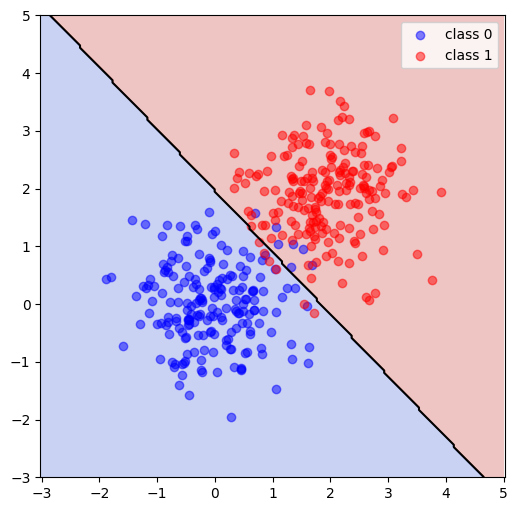

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator

np.random.seed(0)
M = 200
X0 = np.random.multivariate_normal([0,0], [[0.5,0],[0,0.5]], M)
X1 = np.random.multivariate_normal([2,2], [[0.5,0],[0,0.5]], M)
X = np.vstack((X0, X1))
y = np.array([0]*M + [1]*M)

class myLDA(BaseEstimator):
    def __init__(self):
        pass

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.means_ = np.array([X[y==c].mean(axis=0) for c in self.classes_])
        self.cov_ = np.cov(X.T)
        self.inv_cov_ = np.linalg.inv(self.cov_)
        self.priors_ = np.array([np.mean(y==c) for c in self.classes_])
        return self

    def predict(self, X):
        scores = []
        for i, c in enumerate(self.classes_):
            diff = X - self.means_[i]
            score = -0.5 * np.sum(diff @ self.inv_cov_ * diff, axis=1) + np.log(self.priors_[i])
            scores.append(score)
        return np.argmax(scores, axis=0)

lda = myLDA()
lda.fit(X, y)
xx, yy = np.meshgrid(np.linspace(-3,5,200), np.linspace(-3,5,200))
grid = np.stack((xx.flatten(), yy.flatten()), axis=1)
Z = lda.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X0[:,0], X0[:,1], c='blue', alpha=0.5, label='class 0')
plt.scatter(X1[:,0], X1[:,1], c='red', alpha=0.5, label='class 1')
plt.contour(xx, yy, Z, levels=[0.5], colors='k')
plt.legend()
plt.axis("equal")
plt.show()

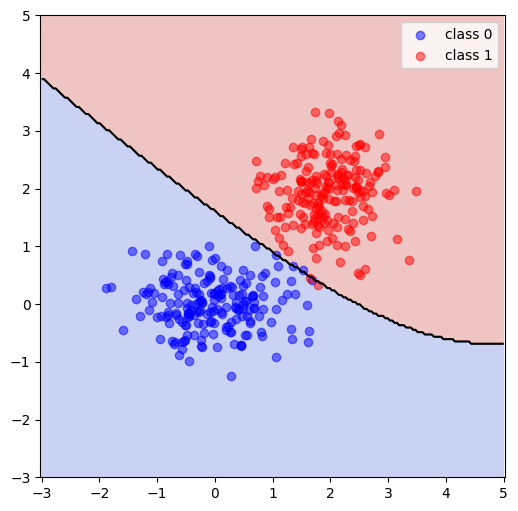

In [5]:
import numpy as np
from sklearn.base import BaseEstimator

np.random.seed(0)
M = 200
X0 = np.random.multivariate_normal([0,0], [[0.5,0],[0,0.2]], M)
X1 = np.random.multivariate_normal([2,2], [[0.3,0],[0,0.3]], M)
X = np.vstack((X0, X1))
y = np.array([0]*M + [1]*M)

class myNB(BaseEstimator):
    def __init__(self):
        pass

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.means_ = np.array([X[y==c].mean(axis=0) for c in self.classes_])
        self.vars_ = np.array([X[y==c].var(axis=0) for c in self.classes_])
        self.priors_ = np.array([np.mean(y==c) for c in self.classes_])
        return self

    def predict(self, X):
        scores = []
        for i, c in enumerate(self.classes_):
            mean = self.means_[i]
            var = self.vars_[i]
            log_prob = -0.5 * np.sum(np.log(2*np.pi*var) + ((X - mean)**2)/var, axis=1) + np.log(self.priors_[i])
            scores.append(log_prob)
        return np.argmax(scores, axis=0)
nb = myNB()
nb.fit(X, y)

import matplotlib.pyplot as plt
xx, yy = np.meshgrid(np.linspace(-3,5,200), np.linspace(-3,5,200))
grid = np.stack((xx.flatten(), yy.flatten()), axis=1)
Z = nb.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X0[:,0], X0[:,1], c='blue', alpha=0.5, label='class 0')
plt.scatter(X1[:,0], X1[:,1], c='red', alpha=0.5, label='class 1')
plt.contour(xx, yy, Z, levels=[0.5], colors='k')
plt.legend()
plt.axis("equal")
plt.show()


### 6. Сравнение двух алгоритмов: LDA и NB

Создайте датасет для бинарной классификации, либо вручную либо используйте функцию `sklearn.datasets.make_classification`
(https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html)  

Разделите датасет на обучающую и тестовую подвыборки.  
Проверьте работоспособность разработанных вами двух алгоритмов.  
Посчитайте основные метрики классификации: долю правильных ответов (accuracy), точность (Precision) и полноту (Recall).  
(про метрики прочитайте здесь https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii)  
Сделайте выводы.  

In [6]:
import numpy as np
from sklearn.base import BaseEstimator
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

X, y = make_classification(n_samples=500, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

#  LDA
class myLDA(BaseEstimator):
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.means_ = np.array([X[y==c].mean(axis=0) for c in self.classes_])
        self.cov_ = np.cov(X.T)
        self.inv_cov_ = np.linalg.inv(self.cov_)
        self.priors_ = np.array([np.mean(y==c) for c in self.classes_])
        return self
    def predict(self, X):
        scores = []
        for i, c in enumerate(self.classes_):
            diff = X - self.means_[i]
            score = -0.5 * np.sum(diff @ self.inv_cov_ * diff, axis=1) + np.log(self.priors_[i])
            scores.append(score)
        return np.argmax(scores, axis=0)
#Naive Bayes
class myNB(BaseEstimator):
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.means_ = np.array([X[y==c].mean(axis=0) for c in self.classes_])
        self.vars_ = np.array([X[y==c].var(axis=0) for c in self.classes_])
        self.priors_ = np.array([np.mean(y==c) for c in self.classes_])
        return self
    def predict(self, X):
        scores = []
        for i, c in enumerate(self.classes_):
            mean = self.means_[i]
            var = self.vars_[i]
            log_prob = -0.5 * np.sum(np.log(2*np.pi*var) + ((X - mean)**2)/var, axis=1) + np.log(self.priors_[i])
            scores.append(log_prob)
        return np.argmax(scores, axis=0)

lda = myLDA().fit(X_train, y_train)
nb = myNB().fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)
y_pred_nb = nb.predict(X_test)

def print_metrics(y_true, y_pred, name):
    print(f"Метрики для {name}:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print()

print_metrics(y_test, y_pred_lda, "LDA")
print_metrics(y_test, y_pred_nb, "Naive Bayes")


Метрики для LDA:
Accuracy: 0.86
Precision: 0.9117647058823529
Recall: 0.8051948051948052

Метрики для Naive Bayes:
Accuracy: 0.8266666666666667
Precision: 0.8148148148148148
Recall: 0.8571428571428571

